# Предобработка базы MIT-BIH для классификации сердечных сокращений

Загружаем сигналы ЭКГ из базы MIT-BIH (формат CSV + аннотации TXT), выполняем фильтрацию, нормализацию и сегментацию отдельных сердечных циклов вокруг R-пиков. Результат сохраняется в сжатый `.npz` файл для дальнейшего обучения моделей.

**Основные шаги:**
1. Загрузка сигнала и аннотаций из файлов CSV/TXT.
2. Полосовая фильтрация (0.5–40 Гц) + режекторный фильтр (50 Гц).
3. Z-нормализация сигнала.
4. Нарезка окон `[R-100, R+150]` отсчётов (250 точек).
5. Отображение примеров сегментов по классам AAMI.
6. Сохранение подготовленных данных.

## Импорт модулей и определение путей

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
from tqdm import tqdm
from collections import Counter

# Путь к папке с данными MIT-BIH (CSV + TXT)
DATA_PATH = './mitbih_database/'

# Частота дискретизации MIT-BIH
FS = 360

# Список всех записей, используемых в базе
RECORDS = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

## Функции загрузки и предобработки

In [2]:
def load_record(record_name, data_path=DATA_PATH, channel=0):
    """
    Загружает один сигнал ЭКГ и аннотации из CSV/TXT файлов MIT-BIH.
    
    Параметры:
    - record_name: имя записи (например '100')
    - data_path: путь к папке с файлами
    - channel: 0 — первое отведение (обычно MLII), 1 — второе (V5)
    
    Возвращает:
    - signal: массив ЭКГ в милливольтах
    - r_peaks: индексы R-пиков (отсчёты)
    - labels: символы аннотаций MIT-BIH
    """
    csv_path = os.path.join(data_path, f'{record_name}.csv')
    df = pd.read_csv(csv_path)
    df.columns = [c.strip().strip("'").strip('"') for c in df.columns]
    
    signal_cols = [c for c in df.columns if c.lower() != 'sample #']
    if channel >= len(signal_cols):
        raise ValueError(f"Канал {channel} не существует в {record_name}. Доступны: {signal_cols}")
    
    signal = df[signal_cols[channel]].to_numpy(dtype=np.float32)
    # Перевод из ADC-единиц в милливольты (gain=200, base=1024)
    signal = (signal - 1024.0) / 200.0
    
    # Загрузка аннотаций
    ann_path = os.path.join(data_path, f'{record_name}annotations.txt')
    r_peaks, labels = [], []
    with open(ann_path, 'r') as f:
        f.readline()  # пропустить заголовок
        for line in f:
            if not line.strip():
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            try:
                sample = int(parts[1])
                symbol = parts[2]
            except (ValueError, IndexError):
                continue
            r_peaks.append(sample)
            labels.append(symbol)
    
    return signal, np.array(r_peaks, dtype=np.int64), np.array(labels)


def bandpass_filter(signal, fs=FS, lowcut=0.5, highcut=40.0, order=4):
    """Полосовой фильтр Баттерворта 0.5–40 Гц."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)


def notch_filter(signal, fs=FS, freq=50.0, quality=30.0):
    """Режекторный фильтр для подавления сетевой наводки 50 Гц."""
    b, a = iirnotch(freq / (fs / 2), quality)
    return filtfilt(b, a, signal)


def denoise(signal, fs=FS):
    """Применяет полосовую фильтрацию и режекцию 50 Гц."""
    signal = bandpass_filter(signal, fs=fs)
    signal = notch_filter(signal, fs=fs, freq=50.0)
    return signal


def zscore_normalize(signal, eps=1e-8):
    """Z-нормализация (среднее=0, std=1)."""
    return (signal - np.mean(signal)) / (np.std(signal) + eps)


# Параметры окна вокруг R-пика (100 отсчётов до, 150 после = 250 точек)
WINDOW_BEFORE = 100
WINDOW_AFTER = 150
WINDOW_SIZE = WINDOW_BEFORE + WINDOW_AFTER   # 250

# Маппинг символов MIT-BIH в 5 классов AAMI
AAMI_MAPPING = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',   # Normal
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',             # Supraventricular ectopic
    'V': 'V', 'E': 'V',                                 # Ventricular ectopic
    'F': 'F',                                           # Fusion
    '/': 'Q', 'f': 'Q', 'Q': 'Q'                        # Unknown
}
CLASS_TO_IDX = {'N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4}


def segment_beats(signal, r_peaks, labels, before=WINDOW_BEFORE, after=WINDOW_AFTER):
    """
    Нарезает сигнал на окна вокруг каждого R-пика.
    Возвращает:
    - beats: массив формы (N_beats, window_size)
    - beat_labels: массив целочисленных меток (0..4)
    """
    beats, beat_labels = [], []
    n = len(signal)
    for r_peak, symbol in zip(r_peaks, labels):
        if symbol not in AAMI_MAPPING:
            continue
        start = r_peak - before
        end = r_peak + after
        if start < 0 or end > n:
            continue
        segment = signal[start:end]
        aami_class = AAMI_MAPPING[symbol]
        beats.append(segment)
        beat_labels.append(CLASS_TO_IDX[aami_class])
    return np.array(beats), np.array(beat_labels)


def process_all_records(records=RECORDS, data_path=DATA_PATH):
    """Обрабатывает все записи, возвращает X, y и идентификаторы пациентов."""
    X_all, y_all, patient_ids = [], [], []
    for rec in tqdm(records, desc='Обработка записей'):
        try:
            signal, r_peaks, labels = load_record(rec, data_path)
        except Exception as e:
            print(f'Ошибка при чтении {rec}: {e}')
            continue
        signal = denoise(signal)
        signal = zscore_normalize(signal)
        beats, beat_labels = segment_beats(signal, r_peaks, labels)
        X_all.append(beats)
        y_all.append(beat_labels)
        patient_ids.append(np.full(len(beats), int(rec)))
    X = np.concatenate(X_all, axis=0)
    y = np.concatenate(y_all, axis=0)
    pids = np.concatenate(patient_ids, axis=0)
    return X, y, pids

## Проверка загрузки одной записи (например, 100)

In [3]:
signal, r_peaks, labels = load_record('100')
print(f"Длина сигнала: {len(signal)} отсчётов ({len(signal)/FS:.1f} сек)")
print(f"Количество аннотаций: {len(r_peaks)}")
print(f"Первые 5 меток: {labels[:5]}")
print(f"Первые 5 R-пиков (индексы): {r_peaks[:5]}")

Длина сигнала: 650000 отсчётов (1805.6 сек)
Количество аннотаций: 2274
Первые 5 меток: ['+' 'N' 'N' 'N' 'N']
Первые 5 R-пиков (индексы): [ 18  77 370 662 946]


## Обработка всех записей из списка RECORDS

> **Примечание:** Папка `DATA_PATH` содержит все `.csv` и `annotations.txt` файлы для указанных записей. Если какой-то файл отсутствует, запись будет пропущена с выводом ошибки.

In [8]:
X, y, pids = process_all_records()
print(f'Форма X: {X.shape}')   # (количество битов, 250)
print(f'Форма y: {y.shape}')
print(f'Форма pids: {pids.shape}')

Обработка записей: 100%|██████████| 48/48 [00:15<00:00,  3.05it/s]

Форма X: (109449, 250)
Форма y: (109449,)
Форма pids: (109449,)


## Распределение классов AAMI

In [5]:
class_names = ['N (Normal)', 'S (Supraventricular ectopic)', 'V (Ventricular ectopic)', 'F (Fusion)', 'Q (Unknown)']
print("Распределение классов:")
for idx, name in enumerate(class_names):
    count = np.sum(y == idx)
    print(f'  {name}: {count:>6} ({100*count/len(y):.2f}%)')

Распределение классов:
  N (Normal):  90592 (82.77%)
  S (Supraventricular ectopic):   2781 (2.54%)
  V (Ventricular ectopic):   7235 (6.61%)
  F (Fusion):    802 (0.73%)
  Q (Unknown):   8039 (7.34%)


## Визуализация примеров сегментов по классам

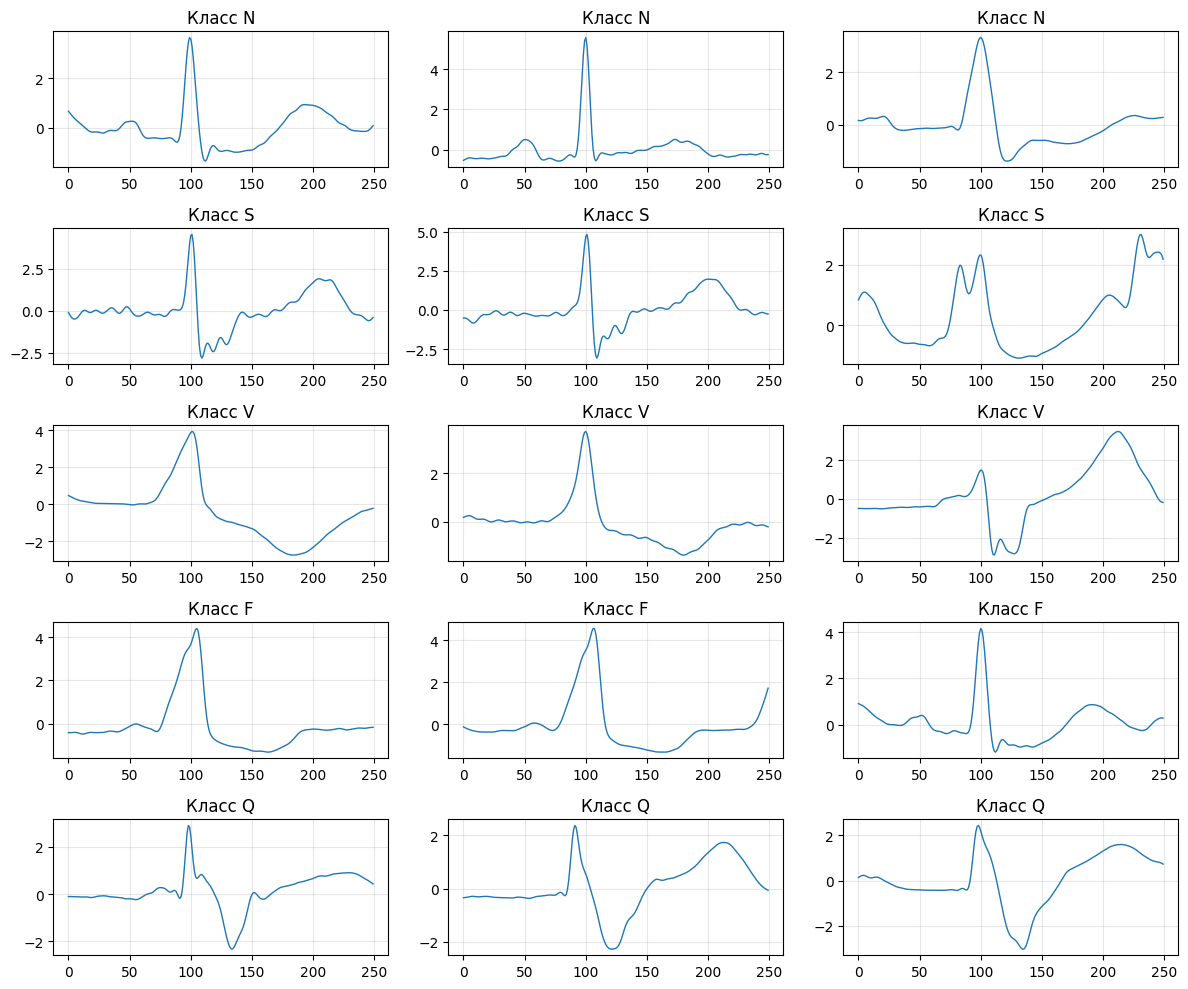

In [6]:
def plot_examples(X, y, n_per_class=3):
    fig, axes = plt.subplots(5, n_per_class, figsize=(12, 10))
    class_short = ['N', 'S', 'V', 'F', 'Q']
    for cls_idx, short in enumerate(class_short):
        idxs = np.where(y == cls_idx)[0]
        if len(idxs) == 0:
            continue
        chosen = np.random.choice(idxs, min(n_per_class, len(idxs)), replace=False)
        for j, beat_idx in enumerate(chosen):
            ax = axes[cls_idx, j]
            ax.plot(X[beat_idx], linewidth=1)
            ax.set_title(f'Класс {short}')
            ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_examples(X, y)

## Сохранение подготовленных данных

Данные сохраняются в сжатый файл `mitbih_preprocessed.npz`, содержащий массивы `X`, `y`, `pids`.

In [7]:
np.savez_compressed(
    'mitbih_preprocessed.npz',
    X=X.astype(np.float32),
    y=y.astype(np.int64),
    pids=pids.astype(np.int32)
)
print("Данные сохранены в 'mitbih_preprocessed.npz'")

Данные сохранены в 'mitbih_preprocessed.npz'



Загрузить файл `mitbih_preprocessed.npz` для обучения моделей классификации сердечных сокращений.

```python
data = np.load('mitbih_preprocessed.npz')
X, y, pids = data['X'], data['y'], data['pids']
```